# UFO Sightings — Análise Exploratória + Plano de Expansões

**Dataset:** [`sahityasetu/ufo-sightings`](https://www.kaggle.com/datasets/sahityasetu/ufo-sightings) (Kaggle), derivado do banco do **NUFORC** (National UFO Reporting Center).

**Objetivo:** explorar a base, mapear o que é possível extrair e propor expansões criativas integrando outras APIs (NASA, clima, terremotos, ISS, etc.) para chegar em análises "doidas" — cruzando avistamentos com a realidade física e cultural.

## Sumário
1. Plano de pesquisa e perguntas
2. Setup e download da base via `kagglehub`
3. Carga e visão geral
4. Limpeza / parsing
5. EDA temporal (ano, mês, hora, dia da semana)
6. EDA geográfica (países, estados, cidades, mapa)
7. EDA categórica (formato/shape) e duração
8. EDA textual (comentários)
9. Achados
10. **Expansões "doidas"** — integrações com APIs externas

---

## 1. Plano de pesquisa

Perguntas que a base sozinha responde:
- Quando as pessoas mais avistam UFOs? (ano, mês, hora, dia da semana)
- Onde estão concentrados? (país, estado, cidade, lat/lon)
- Qual o **shape** mais comum?
- Qual a duração típica? (existem outliers absurdos?)
- Existe um **lag de reporte** (tempo entre avistamento e postagem)?
- O texto livre revela palavras/temas recorrentes?

Perguntas que **só** ficam interessantes cruzando com outras fontes (ver seção 10):
- Avistamentos batem com **lançamentos de foguetes / reentradas** (NASA / SpaceX / Space-Track)?
- Coincidem com **chuvas de meteoros** conhecidas?
- Têm correlação com **passagens da ISS** sobre o céu local?
- Concentram-se perto de **bases militares / sítios nucleares / aeroportos**?
- Reagem a **eventos climáticos** (tempestades, núcleos convectivos, lenticulares)?
- Casam com **picos culturais** (estreias de filmes de ficção, manchetes virais)?
- Crescem com **densidade populacional + poluição luminosa** (viés de observador)?

Referências consultadas: Gigasheet EDA 101, repositório `timothyrenner/nuforc_sightings_data`, artigos History/Vice sobre nuclear sites, Open-Meteo Historical API, NASA Open APIs.

## 2. Setup e download

Se algum pacote estiver faltando, descomente a célula abaixo e rode uma vez.

In [8]:
!pip install -q kagglehub pandas numpy matplotlib seaborn
!pip install -q pandas numpy matplotlib seaborn

In [9]:
import os
import re
import glob
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

In [10]:
import kagglehub

# Baixa a versão mais recente do dataset (cache local em ~/.cache/kagglehub)
path = kagglehub.dataset_download("sahityasetu/ufo-sightings")
print("Path to dataset files:", path)

# Lista o conteúdo da pasta baixada
for root, _, files in os.walk(path):
    for f in files:
        full = os.path.join(root, f)
        size_mb = os.path.getsize(full) / (1024 * 1024)
        print(f"{size_mb:7.2f} MB  {full}")

100%|██████████| 4.88M/4.88M [00:01<00:00, 4.63MB/s]

Extracting files...


Path to dataset files: /home/bonru/.cache/kagglehub/datasets/sahityasetu/ufo-sightings/versions/1
  13.54 MB  /home/bonru/.cache/kagglehub/datasets/sahityasetu/ufo-sightings/versions/1/ufo_sightings_scrubbed.csv


## 3. Carga e visão geral

In [11]:
# Localiza o CSV principal dentro da pasta baixada
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("CSVs encontrados:", csv_files)

# Pega o maior CSV (geralmente é o dataset principal)
csv_path = max(csv_files, key=os.path.getsize)
print("Usando:", csv_path)

# Tenta ler com tolerância a linhas problemáticas
df = pd.read_csv(csv_path, low_memory=False, on_bad_lines="skip")
print("Shape:", df.shape)
df.head()

CSVs encontrados: ['/home/bonru/.cache/kagglehub/datasets/sahityasetu/ufo-sightings/versions/1/ufo_sightings_scrubbed.csv']
Usando: /home/bonru/.cache/kagglehub/datasets/sahityasetu/ufo-sightings/versions/1/ufo_sightings_scrubbed.csv
Shape: (80332, 11)


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,2004-04-27,29.8830556,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,2005-12-16,29.38421,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,2008-01-21,53.2,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,2004-01-17,28.9783333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,2004-01-22,21.4180556,-157.803611


In [12]:
# Tipos e nulos
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "%nulos": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(dropna=True),
})
info.sort_values("%nulos", ascending=False)

,dtype,nulos,%nulos,unicos
country,str,9670,12.04,5
state,str,5797,7.22,67
shape,str,1932,2.41,29
comments,str,15,0.02,79997
datetime,str,0,0.00,69474
city,str,0,0.00,19900
duration (seconds),str,0,0.00,536
duration (hours/min),str,0,0.00,8304
date posted,str,0,0.00,317
latitude,str,0,0.00,18421


In [13]:
# Estatísticas descritivas (numéricas + texto)
df.describe(include="all").T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
datetime,80332,69474,2010-07-04 22:00:00,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,80332,19900,seattle,525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,74535,67,ca,9655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,70662,5,us,65114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shape,78400,29,light,16565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration (seconds),80332,536,300,8635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration (hours/min),80332,8304,5 minutes,4716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
comments,80317,79997,Fireball,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date posted,80332,317,2009-12-12,1510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,80332,18421,47.6063889,581,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Limpeza e parsing

A base do NUFORC tipicamente tem colunas como: `datetime`, `city`, `state`, `country`, `shape`, `duration (seconds)`, `duration (hours/min)`, `comments`, `date posted`, `latitude`, `longitude`. Os nomes podem variar entre versões — o código abaixo tenta detectar dinamicamente.

In [14]:
# Normaliza nomes de colunas
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print(list(df.columns))

['datetime', 'city', 'state', 'country', 'shape', 'duration_(seconds)', 'duration_(hours/min)', 'comments', 'date_posted', 'latitude', 'longitude']


In [15]:
def find_col(candidates):
    """Retorna o primeiro nome de coluna que casa com qualquer candidato (substring)."""
    for cand in candidates:
        for col in df.columns:
            if cand in col:
                return col
    return None

col_datetime = find_col(["datetime", "date_time", "occurred"])
col_posted   = find_col(["date_posted", "posted"])
col_country  = find_col(["country"])
col_state    = find_col(["state"])
col_city     = find_col(["city"])
col_shape    = find_col(["shape"])
col_dur_s    = find_col(["duration_(seconds)", "duration_seconds", "seconds"])
col_dur_t    = find_col(["duration_(hours", "duration_hours", "duration"])
col_lat      = find_col(["latitude"])
col_lon      = find_col(["longitude"])
col_text     = find_col(["comments", "summary", "text", "description"])

print({
    "datetime": col_datetime, "posted": col_posted, "country": col_country,
    "state": col_state, "city": col_city, "shape": col_shape,
    "dur_s": col_dur_s, "dur_t": col_dur_t,
    "lat": col_lat, "lon": col_lon, "text": col_text,
})

{'datetime': 'datetime', 'posted': 'date_posted', 'country': 'country', 'state': 'state', 'city': 'city', 'shape': 'shape', 'dur_s': 'duration_(seconds)', 'dur_t': 'duration_(hours/min)', 'lat': 'latitude', 'lon': 'longitude', 'text': 'comments'}


In [16]:
# Parse de datas
if col_datetime:
    df["dt"] = pd.to_datetime(df[col_datetime], errors="coerce")
if col_posted:
    df["dt_posted"] = pd.to_datetime(df[col_posted], errors="coerce")

# Lat/lon para numérico
if col_lat:
    df["lat"] = pd.to_numeric(df[col_lat], errors="coerce")
if col_lon:
    df["lon"] = pd.to_numeric(df[col_lon], errors="coerce")

# Duração em segundos
if col_dur_s:
    df["dur_s"] = pd.to_numeric(df[col_dur_s], errors="coerce")

# Lag de reporte (em dias)
if "dt" in df.columns and "dt_posted" in df.columns:
    df["lag_dias"] = (df["dt_posted"] - df["dt"]).dt.days

# Campos derivados de tempo
if "dt" in df.columns:
    df["ano"] = df["dt"].dt.year
    df["mes"] = df["dt"].dt.month
    df["hora"] = df["dt"].dt.hour
    df["dia_semana"] = df["dt"].dt.day_name()

df.head(3)

,datetime,city,state,country,shape,duration_(seconds),duration_(hours/min),comments,date_posted,latitude,longitude,dt,dt_posted,lat,lon,dur_s,lag_dias,ano,mes,hora,dia_semana
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,2004-04-27,29.8830556,-97.941111,1949-10-10 20:30:00,2004-04-27,29.883056,-97.941111,2700.0,19922,1949,10,20,Monday
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,2005-12-16,29.38421,-98.581082,1949-10-10 21:00:00,2005-12-16,29.384210,-98.581082,7200.0,20520,1949,10,21,Monday
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,2008-01-21,53.2,-2.916667,1955-10-10 17:00:00,2008-01-21,53.200000,-2.916667,20.0,19095,1955,10,17,Monday


## 5. EDA Temporal

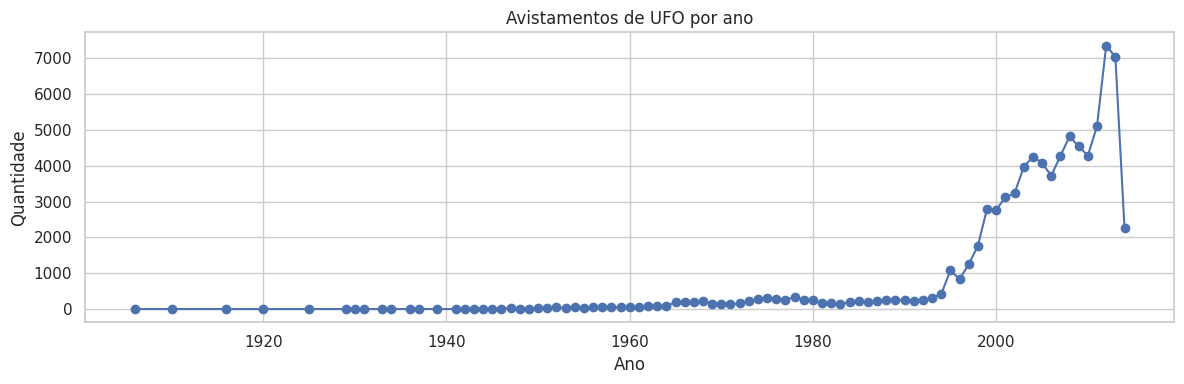

In [17]:
# Avistamentos por ano
if "ano" in df.columns:
    por_ano = df["ano"].dropna().astype(int)
    por_ano = por_ano[(por_ano >= 1900) & (por_ano <= 2025)].value_counts().sort_index()
    plt.figure(figsize=(12, 4))
    por_ano.plot(kind="line", marker="o")
    plt.title("Avistamentos de UFO por ano")
    plt.xlabel("Ano"); plt.ylabel("Quantidade")
    plt.tight_layout(); plt.show()

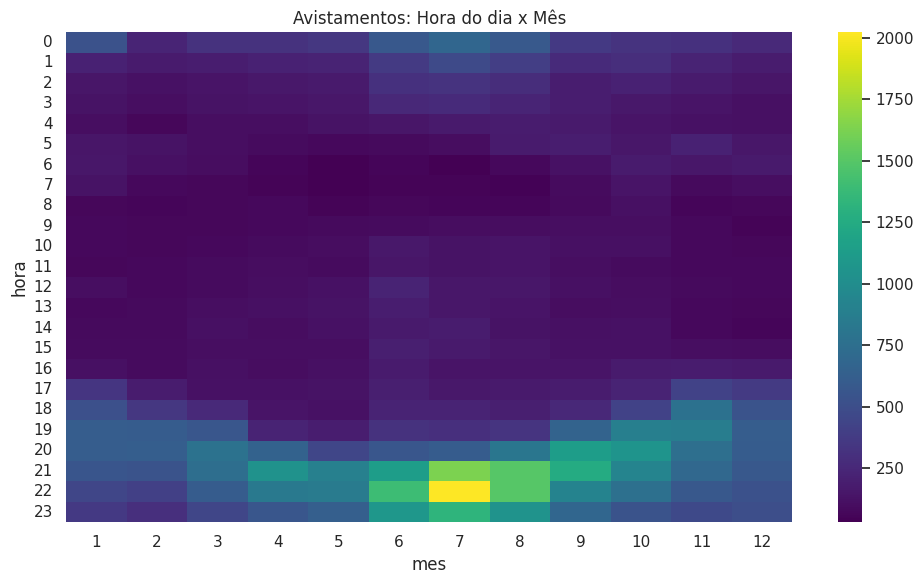

In [18]:
# Mês x Hora — heatmap (quando o céu "abre" para os ETs)
if {"mes", "hora"}.issubset(df.columns):
    piv = df.dropna(subset=["mes", "hora"]).pivot_table(
        index="hora", columns="mes", values=df.columns[0], aggfunc="count"
    )
    plt.figure(figsize=(10, 6))
    sns.heatmap(piv, cmap="viridis")
    plt.title("Avistamentos: Hora do dia x Mês")
    plt.tight_layout(); plt.show()

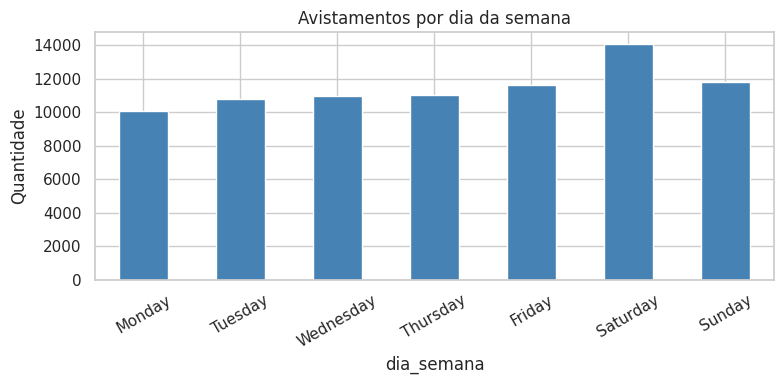

In [19]:
# Dia da semana
if "dia_semana" in df.columns:
    ordem = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    cont = df["dia_semana"].value_counts().reindex(ordem)
    plt.figure(figsize=(8, 4))
    cont.plot(kind="bar", color="steelblue")
    plt.title("Avistamentos por dia da semana")
    plt.ylabel("Quantidade"); plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()

count    69562.000000
mean       118.038872
std        303.217313
min          0.000000
25%          7.000000
50%         20.000000
75%         51.000000
max       1825.000000
Name: lag_dias, dtype: float64


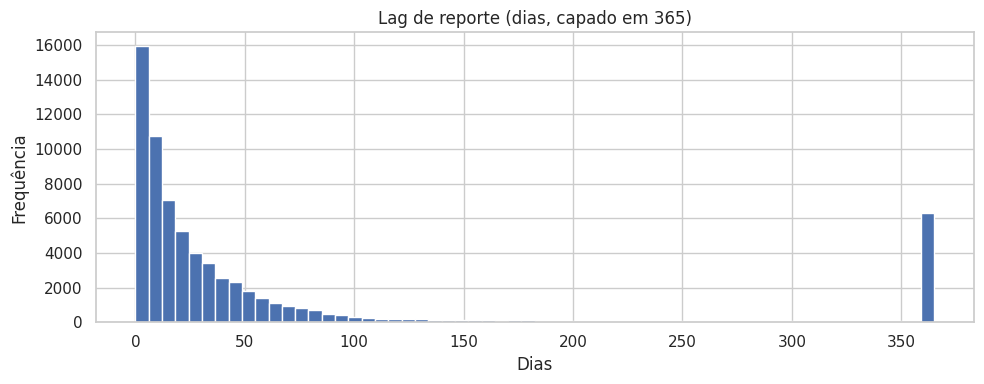

In [20]:
# Lag de reporte: quanto tempo a pessoa demora para reportar
if "lag_dias" in df.columns:
    lag = df["lag_dias"].dropna()
    lag = lag[(lag >= 0) & (lag <= 365 * 5)]
    print(lag.describe())
    plt.figure(figsize=(10, 4))
    lag.clip(upper=365).hist(bins=60)
    plt.title("Lag de reporte (dias, capado em 365)")
    plt.xlabel("Dias"); plt.ylabel("Frequência")
    plt.tight_layout(); plt.show()

## 6. EDA Geográfica

In [21]:
# Top países / estados / cidades
if col_country:
    print("Top países:\n", df[col_country].value_counts().head(10))
if col_state:
    print("\nTop estados:\n", df[col_state].value_counts().head(10))
if col_city:
    print("\nTop cidades:\n", df[col_city].value_counts().head(10))

Top países:
 country
us    65114
ca     3000
gb     1905
au      538
de      105
Name: count, dtype: int64

Top estados:
 state
ca    9655
wa    4268
fl    4200
tx    3677
ny    3219
az    2689
il    2645
pa    2582
oh    2425
mi    2071
Name: count, dtype: int64

Top cidades:
 city
seattle        525
phoenix        454
portland       374
las vegas      368
los angeles    353
san diego      338
houston        297
chicago        265
tucson         241
miami          239
Name: count, dtype: int64


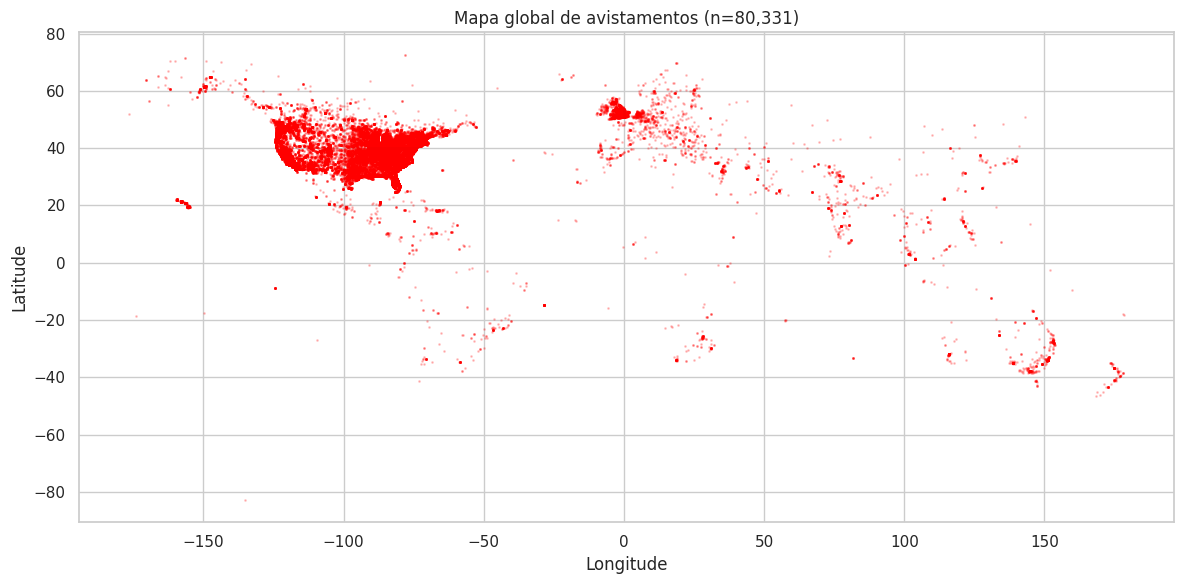

In [22]:
# Mapa de dispersão (lat/lon) — densidade global
if {"lat", "lon"}.issubset(df.columns):
    geo = df.dropna(subset=["lat", "lon"])
    geo = geo[(geo["lat"].between(-90, 90)) & (geo["lon"].between(-180, 180))]
    plt.figure(figsize=(12, 6))
    plt.scatter(geo["lon"], geo["lat"], s=1, alpha=0.2, c="red")
    plt.title(f"Mapa global de avistamentos (n={len(geo):,})")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.tight_layout(); plt.show()

## 7. EDA Categórica e Duração

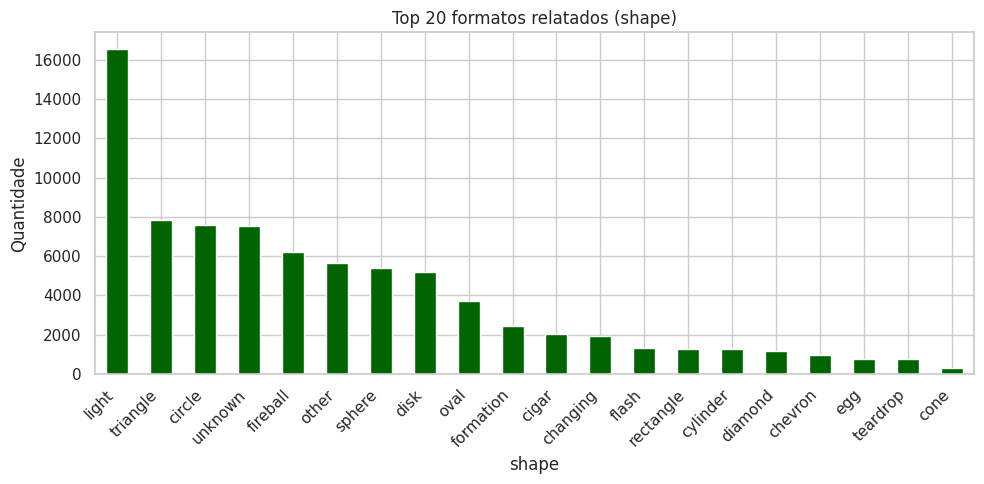

In [23]:
# Distribuição de shapes
if col_shape:
    cont = df[col_shape].fillna("unknown").str.lower().value_counts().head(20)
    plt.figure(figsize=(10, 5))
    cont.plot(kind="bar", color="darkgreen")
    plt.title("Top 20 formatos relatados (shape)")
    plt.ylabel("Quantidade"); plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

count    8.032900e+04
mean     9.017226e+03
std      6.202284e+05
min      1.000000e-03
25%      3.000000e+01
50%      1.800000e+02
75%      6.000000e+02
max      9.783600e+07
Name: dur_s, dtype: float64


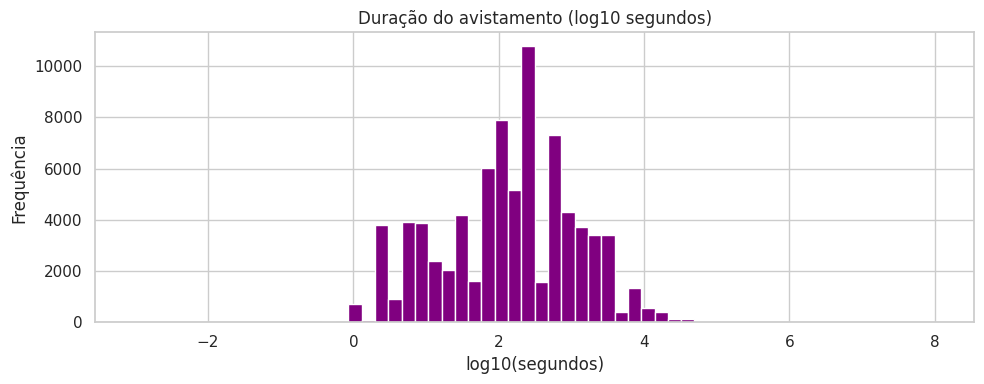

In [24]:
# Duração — escala log porque tem outliers absurdos (avistamentos de "anos"!)
if "dur_s" in df.columns:
    d = df["dur_s"].dropna()
    d = d[d > 0]
    print(d.describe())
    plt.figure(figsize=(10, 4))
    np.log10(d).hist(bins=60, color="purple")
    plt.title("Duração do avistamento (log10 segundos)")
    plt.xlabel("log10(segundos)"); plt.ylabel("Frequência")
    plt.tight_layout(); plt.show()

## 8. EDA Textual (comentários)

In [25]:
# Top palavras nos comentários (sem libs externas)
if col_text:
    stop = set("""a o e de da do em um uma para com no na que se foi por
    the and a an of in on to for with at as is was were it this that be by
    we i my our they them he she his her not but or from had has have but
    object light lights sky like saw seen see one two three about over very
    """.split())
    sample = df[col_text].dropna().astype(str).sample(min(20000, len(df)), random_state=42)
    words = re.findall(r"[a-zA-Z]{4,}", " ".join(sample.tolist()).lower())
    words = [w for w in words if w not in stop]
    top = Counter(words).most_common(30)
    pd.DataFrame(top, columns=["palavra", "freq"])  # mostra a tabela

## 9. Achados (preencher após rodar)

Espaço para anotar conclusões depois da execução. Padrões esperados (com base na literatura sobre NUFORC):
- Forte concentração geográfica nos **EUA** (viés do canal de reporte).
- Pico noturno (21h–00h), pico semanal aos **sábados**.
- Crescimento explosivo após **~1995** (efeito internet + X-Files).
- Shape mais comum: **light**.
- Distribuição de duração **fortemente log-normal** com outliers patológicos.
- Lag de reporte enviesado: muitos reportam dias/semanas depois.

---

## 10. Expansões "doidas" — brincando com a realidade

Cada item abaixo é uma **integração concreta** que transforma esta base num projeto sério/divertido de ciência de dados. Todas usam APIs públicas e gratuitas (alguns exigem chave grátis).

### A. Clima no momento do avistamento — Open-Meteo Historical
- Endpoint: `https://archive-api.open-meteo.com/v1/archive?latitude=...&longitude=...&start_date=...&end_date=...&hourly=cloud_cover,visibility,temperature_2m,wind_speed_10m,weather_code`
- **Hipótese**: avistamentos crescem com **céu parcialmente nublado** (nuvens lenticulares, reflexos) ou em **inversões térmicas**.
- Análise: comparar distribuição de `cloud_cover` em horas de avistamento vs. amostra aleatória de horas/locais (controle).

### B. Lançamentos espaciais e reentradas — SpaceX API + Launch Library 2
- `https://ll.thespacedevs.com/2.2.0/launch/` (gratuito, sem chave para uso leve)
- **Hipótese**: picos de avistamentos em janelas de ±48h após lançamentos visíveis (Starlink trains são *icônicos* nisso).
- Análise: contagem de avistamentos em janela ±2 dias x distância do site de lançamento.

### C. Passagens da ISS / satélites brilhantes — N2YO / CelesTrak
- TLEs gratuitos no CelesTrak; biblioteca `skyfield` calcula passagens visíveis.
- **Hipótese**: muitos "UFOs" são satélites em flares (Iridium, Starlink). Quantos avistamentos têm um satélite visível no céu naquele instante?

### D. Chuvas de meteoros — IMO Meteor Shower Calendar
- Datas de pico (Perseidas, Geminidas, Leonidas) anuais.
- **Hipótese**: relatos de "bola de fogo"/"fireball" disparam nas datas de pico.
- Análise: filtrar shape ∈ {fireball, sphere, light} e cruzar com calendário.

### E. Bases militares e sítios nucleares — OpenStreetMap (Overpass API) + lista pública
- Query Overpass por `military=base|airfield` + dataset público de instalações nucleares.
- **Hipótese clássica**: avistamentos clusterizam perto de instalações militares/nucleares (literatura: Malmstrom AFB, Kirtland, Rendlesham).
- Análise: para cada avistamento, distância ao site militar/nuclear mais próximo; teste estatístico contra distribuição de pontos aleatórios na mesma área.

### F. Aeroportos e rotas aéreas — OurAirports CSV + OpenSky Network
- **Hipótese antagônica**: a maioria dos UFOs perto de aeroportos é tráfego comercial. OpenSky tem histórico de voos reais.
- Análise: para uma amostra de avistamentos com lat/lon/hora exatos, quantas aeronaves estavam num raio de 50 km?

### G. Densidade populacional e poluição luminosa — NASA SEDAC / VIIRS
- **Hipótese de viés**: avistamentos refletem **observadores**, não ETs. Normalizar por população (per capita) muda completamente o mapa.
- Análise: mapa per capita; achar **outliers** (cidades com avistamentos muito acima do esperado pela população — esses sim são interessantes).

### H. Cultura pop e mídia — Google Trends + IMDb / Wikipedia pageviews
- **Hipótese**: estreias (X-Files, Independence Day, séries de aliens) e manchetes (Pentagon UAP report 2017/2021) elevam reportagem.
- Análise: regressão de avistamentos mensais contra pageviews de "UFO"/"UAP" na Wikipedia (API pública).

### I. Sismos e atividade geofísica — USGS Earthquake API
- `https://earthquake.usgs.gov/fdsnws/event/1/query`
- **Hipótese exótica ("earthquake lights")**: luminescência associada a estresse tectônico antes/durante terremotos.
- Análise: avistamentos num raio de X km e janela de ±72h em torno de sismos M≥4.

### J. Tempestades solares e auroras — NOAA SWPC / NASA DONKI
- DONKI lista CMEs, tempestades geomagnéticas, flares.
- **Hipótese**: noites de aurora elevam relatos em latitudes médias (luzes estranhas no céu).

### K. NLP avançado nos comentários — embeddings + clusterização
- Sentence-Transformers → UMAP → HDBSCAN.
- Achar **arquétipos narrativos**: "luzes piscando", "triângulo silencioso", "abdução", "chemtrail". Mapear evolução temporal de cada arquétipo.

### L. Modelo preditivo "onde/quando ver um UFO"
- Features: hora, mês, lat/lon, população, cloud_cover, distância a base militar, lançamento espacial recente, pico de meteoros.
- Target: probabilidade de relato no próximo dia naquele tile geográfico (LightGBM, Poisson regression).
- Saída: **mapa-calor preditivo** "chance de UFO hoje".

### M. A análise mais doida de todas — "O Grande Desencantador"
Cruzar A+B+C+D+F simultaneamente para classificar cada avistamento em:
- 🛰️ provavelmente satélite/ISS
- 🚀 provavelmente foguete/reentrada
- ✈️ provavelmente avião comercial
- ☄️ provavelmente meteoro
- 🌩️ provavelmente fenômeno atmosférico
- ❓ **resíduo inexplicável** ← essa é a pilha que importa

Quantos % do banco do NUFORC sobrevive a esse filtro? **Esse é o número que vale a manchete.**

---

## Próximos passos sugeridos
1. Rodar o notebook inteiro e preencher a seção 9.
2. Escolher 2–3 expansões da seção 10 para virar mini-projetos.
3. Recomendado começar por **A (clima)** + **B (lançamentos)** + **G (per capita)** — alto impacto, baixa fricção.